### Persons in the geographical space: specific countries

In this notebook we use regions or political/administrative territories to produce a distribution of the birthplaces of our population.

The data was prepared using the queries [documented on this page](https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/documentation/wikidata/data-analysis/da2-birth-places.sql)

In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString
from shapely import wkt

import scipy.stats as stats
import math

from geopandas.tools import sjoin
#from geodatasets import get_path

In [2]:
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

import json

import numpy as np
import seaborn as sns
import math
import os

In [3]:
import warnings
warnings.filterwarnings('ignore')


In [4]:

import pprint
import csv


from shutil import copyfile


### Italy

In [5]:
### Source: https://simplemaps.com/gis/country/it
italy_filepath = 'geo_data/it_territories.json'
## dataframe GeoPandas
italy = gpd.read_file(italy_filepath)
italy.head()

,source,id,name,geometry
0,https://simplemaps.com,IT23,Valle d'Aosta,"POLYGON ((7.84962 45.93971, 7.85593 45.91932, ..."
1,https://simplemaps.com,IT21,Piedmont,"POLYGON ((7.07537 45.46629, 7.08926 45.47706, ..."
2,https://simplemaps.com,IT42,Liguria,"POLYGON ((7.68793 44.0908, 7.70933 44.09152, 7..."
3,https://simplemaps.com,IT25,Lombardy,"POLYGON ((9.20143 44.68213, 9.20593 44.72083, ..."
4,https://simplemaps.com,IT32,Trentino-Alto Adige,"POLYGON ((10.8449 45.83405, 10.8267 45.84123, ..."


In [6]:
### Inspect the projection
pprint.pprint(italy.crs)

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich



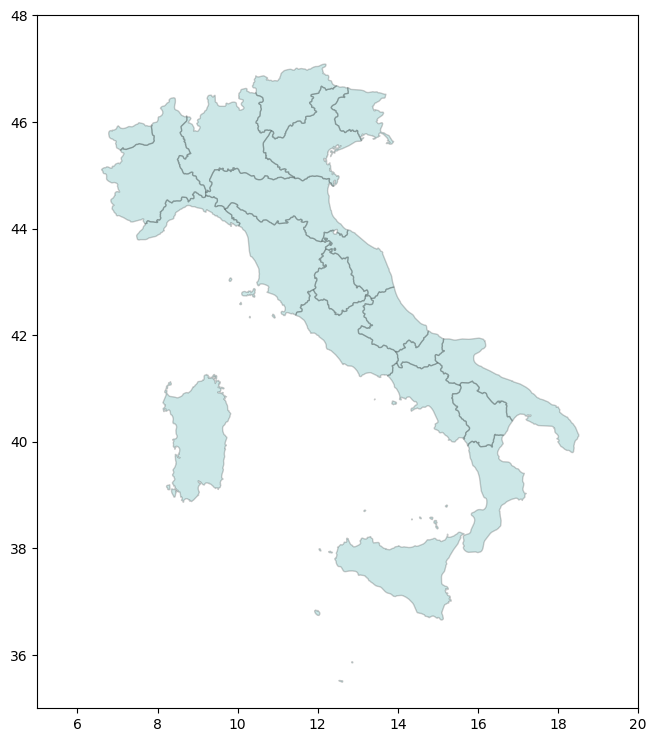

In [7]:
### Draw the map of Italian regions

## GeoPandas documentation
# https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html


ax = italy.plot(color="DarkCyan", alpha=0.2, edgecolor="black", figsize=(12,9))

# If we want to exclude the Antarctic region
ax.set_xlim(5,20)
ax.set_ylim(35, 48)


plt.show()



### France

In [19]:
### Source: https://gadm.org/download_country.html
# For départements d'autre mer see other entries in GADM: 
# French Guiana etc.
france_filepath = 'geo_data/gadm41_FRA_2.json'
## dataframe GeoPandas
france = gpd.read_file(france_filepath)
france.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,FRA.1.1_1,FRA,France,FRA.1_1,Auvergne-Rhône-Alpes,NA,Ain,NA,NA,Département,Department,01,FR.AI,"MULTIPOLYGON (((5.6237 45.6133, 5.6149 45.6254..."
1,FRA.1.2_1,FRA,France,FRA.1_1,Auvergne-Rhône-Alpes,NA,Allier,Basses-Alpes,NA,Département,Department,03,FR.AL,"MULTIPOLYGON (((3.678 45.956, 3.6666 45.9612, ..."
2,FRA.1.3_1,FRA,France,FRA.1_1,Auvergne-Rhône-Alpes,NA,Ardèche,NA,NA,Département,Department,07,FR.AH,"MULTIPOLYGON (((4.1417 44.324, 4.1268 44.3377,..."
3,FRA.1.4_1,FRA,France,FRA.1_1,Auvergne-Rhône-Alpes,NA,Cantal,NA,NA,Département,Department,15,FR.CL,"MULTIPOLYGON (((3.0642 44.8203, 3.0483 44.8043..."
4,FRA.1.5_1,FRA,France,FRA.1_1,Auvergne-Rhône-Alpes,NA,Drôme,NA,NA,Département,Department,26,FR.DM,"MULTIPOLYGON (((5.4476 44.1368, 5.4384 44.1388..."


In [17]:
france = france.rename(columns={'code':'num_dep'})
france.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   GID_2      96 non-null     object  
 1   GID_0      96 non-null     object  
 2   COUNTRY    96 non-null     object  
 3   GID_1      96 non-null     object  
 4   NAME_1     96 non-null     object  
 5   NL_NAME_1  96 non-null     object  
 6   NAME_2     96 non-null     object  
 7   VARNAME_2  96 non-null     object  
 8   NL_NAME_2  96 non-null     object  
 9   TYPE_2     96 non-null     object  
 10  ENGTYPE_2  96 non-null     object  
 11  CC_2       96 non-null     object  
 12  HASC_2     96 non-null     object  
 13  geometry   96 non-null     geometry
dtypes: geometry(1), object(13)
memory usage: 10.6+ KB


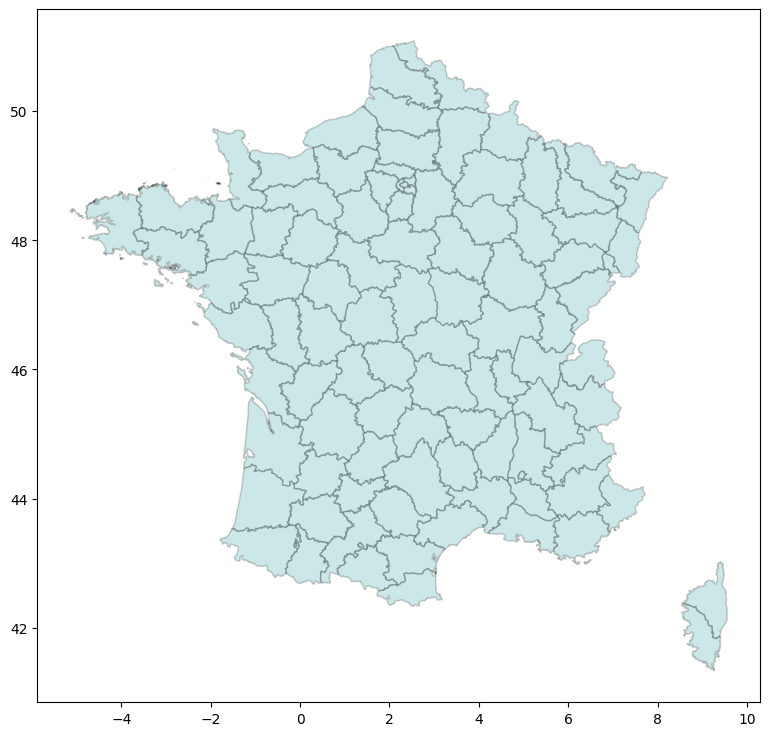

In [18]:
### Draw the world map

## GeoPandas documentation
# https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html


ax = france.plot(color="DarkCyan", alpha=0.2, edgecolor="black", figsize=(12,9))

# If we want to exclude the Antarctic region
#ax.set_xlim(-5,10)
#ax.set_ylim(25, 60)


plt.show()



## Import the data

The data is available in the da_data directory and was prepared using the query [documented on this page](../../documentation/wikidata/data-analysis/da1-distribution-of-births-in-time.md)

In [14]:
## create variable declaring the path to the data
path_to_data = 'da_data/da2-birth-place.csv'

In [15]:
## creating a Pandas Dataframe (data container in form of a table) 
df_p = pd.read_csv(path_to_data, sep=",", encoding="utf-8", header=0)
df_p.columns = ['uriPer', 'labelPer', 'birthYear', 'gender', 'labelPlace',
                'geometry','uriPlace']

## first rows of the dataframe
df_p.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace
0,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,1929,male,Aalen,POINT(10.093611 48.837222),http://www.wikidata.org/entity/Q3951
1,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,1892,male,Holstebro,POINT(8.617500 56.358056),http://www.wikidata.org/entity/Q27678
2,http://www.wikidata.org/entity/Q100153910,Frank J. Blatt,1924,male,Vienna,POINT(16.372500 48.208333),http://www.wikidata.org/entity/Q1741
3,http://www.wikidata.org/entity/Q100155322,Edgar Knobloch,1953,male,Prague,POINT(14.421389 50.087500),http://www.wikidata.org/entity/Q1085
4,http://www.wikidata.org/entity/Q100169285,Robert M. Winglee,1958,male,Sydney,POINT(151.210000 -33.867778),http://www.wikidata.org/entity/Q3130


In [16]:
## Basic infor about the DataFrame
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22080 entries, 0 to 22079
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   uriPer      22080 non-null  object
 1   labelPer    22080 non-null  object
 2   birthYear   22080 non-null  int64 
 3   gender      21986 non-null  object
 4   labelPlace  22080 non-null  object
 5   geometry    22080 non-null  object
 6   uriPlace    22080 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.2+ MB


## Inspect the data


In [17]:
### Tests if the values in the column are unique
# If unique result : True (boolean value not string !)
is_unique=df_p.uriPer.is_unique
print(is_unique)

True


## Group and map birth places

"Well-known text (WKT) is a text markup language for representing vector geometry objects" ([Wikipedia](https://en.wikipedia.org/wiki/Well-known_text_representation_of_geometry))

In [18]:
### Group and count the number of persons per birth place
p_gr = df_p.groupby(by=['uriPlace', 'labelPlace', 'geometry'], as_index=False).size()
p_gr.columns=['uriPlace', 'labelPlace', 'geometry', 'size']
p_gr.sort_values('size', ascending=False).head()


,uriPlace,labelPlace,geometry,size
6879,http://www.wikidata.org/entity/Q649,Moscow,POINT(37.617500 55.750556),493
6810,http://www.wikidata.org/entity/Q64,Berlin,POINT(13.383333 52.516667),341
6943,http://www.wikidata.org/entity/Q656,Saint Petersburg,POINT(30.316667 59.950000),299
6611,http://www.wikidata.org/entity/Q60,New York City,POINT(-74.006111 40.712778),274
2059,http://www.wikidata.org/entity/Q1741,Vienna,POINT(16.372500 48.208333),266


In [19]:
### Try first to convert WKT into Point Geometry
# using a geopandas feature
try:
    p_gr['geometry'] = p_gr['geometry'].apply(wkt.loads)
except Exception as e:
    print(e)

ParseException: Unknown type: '_:BN1612906'


In [20]:
### there are wrong values in the data: find them
# all the rows where the geometry field does not contain the string 'POINT'
df_p.loc[~df_p.geometry.str.contains('POINT')]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace
15083,http://www.wikidata.org/entity/Q5078030,Charles Gifford,1861,male,at sea,_:bn1612906,http://www.wikidata.org/entity/Q55438959


In [21]:
### Drop the rows with the wrong value
df_p=df_p.loc[df_p.geometry.str.contains('POINT')]

In [22]:
### Re-do grouping after cleaning up
p_gr = df_p.groupby(by=['uriPlace', 'labelPlace', 'geometry'], as_index=False).size()
p_gr.columns=['uriPlace', 'labelPlace', 'geometry', 'number']
p_gr.sort_values('number', ascending=False).head(2)


,uriPlace,labelPlace,geometry,number
6878,http://www.wikidata.org/entity/Q649,Moscow,POINT(37.617500 55.750556),493
6809,http://www.wikidata.org/entity/Q64,Berlin,POINT(13.383333 52.516667),341


In [23]:

### Create a dataframe with the POINT geometry
# https://geopandas.org/en/stable/gallery/create_geopandas_from_pandas.html
birth_gdf = gpd.GeoDataFrame(
    p_gr, 
    ### Use this if no conversion before to geometry
    ## Cf. above:  p_gr['geometry'].apply(wkt.loads)
    geometry=gpd.GeoSeries.from_wkt(p_gr.geometry), 
    crs=4326
)

birth_gdf.sort_values('number', ascending=False).head(2)



,uriPlace,labelPlace,geometry,number
6878,http://www.wikidata.org/entity/Q649,Moscow,POINT (37.6175 55.75056),493
6809,http://www.wikidata.org/entity/Q64,Berlin,POINT (13.38333 52.51667),341


In [24]:
### The Python class of the object changed 
# WKT strings are now points
print(p_gr.geometry.dtype, '->', birth_gdf.geometry.dtype)

object -> geometry


In [25]:
### Inspect the projection
pprint.pprint(birth_gdf.crs)

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich



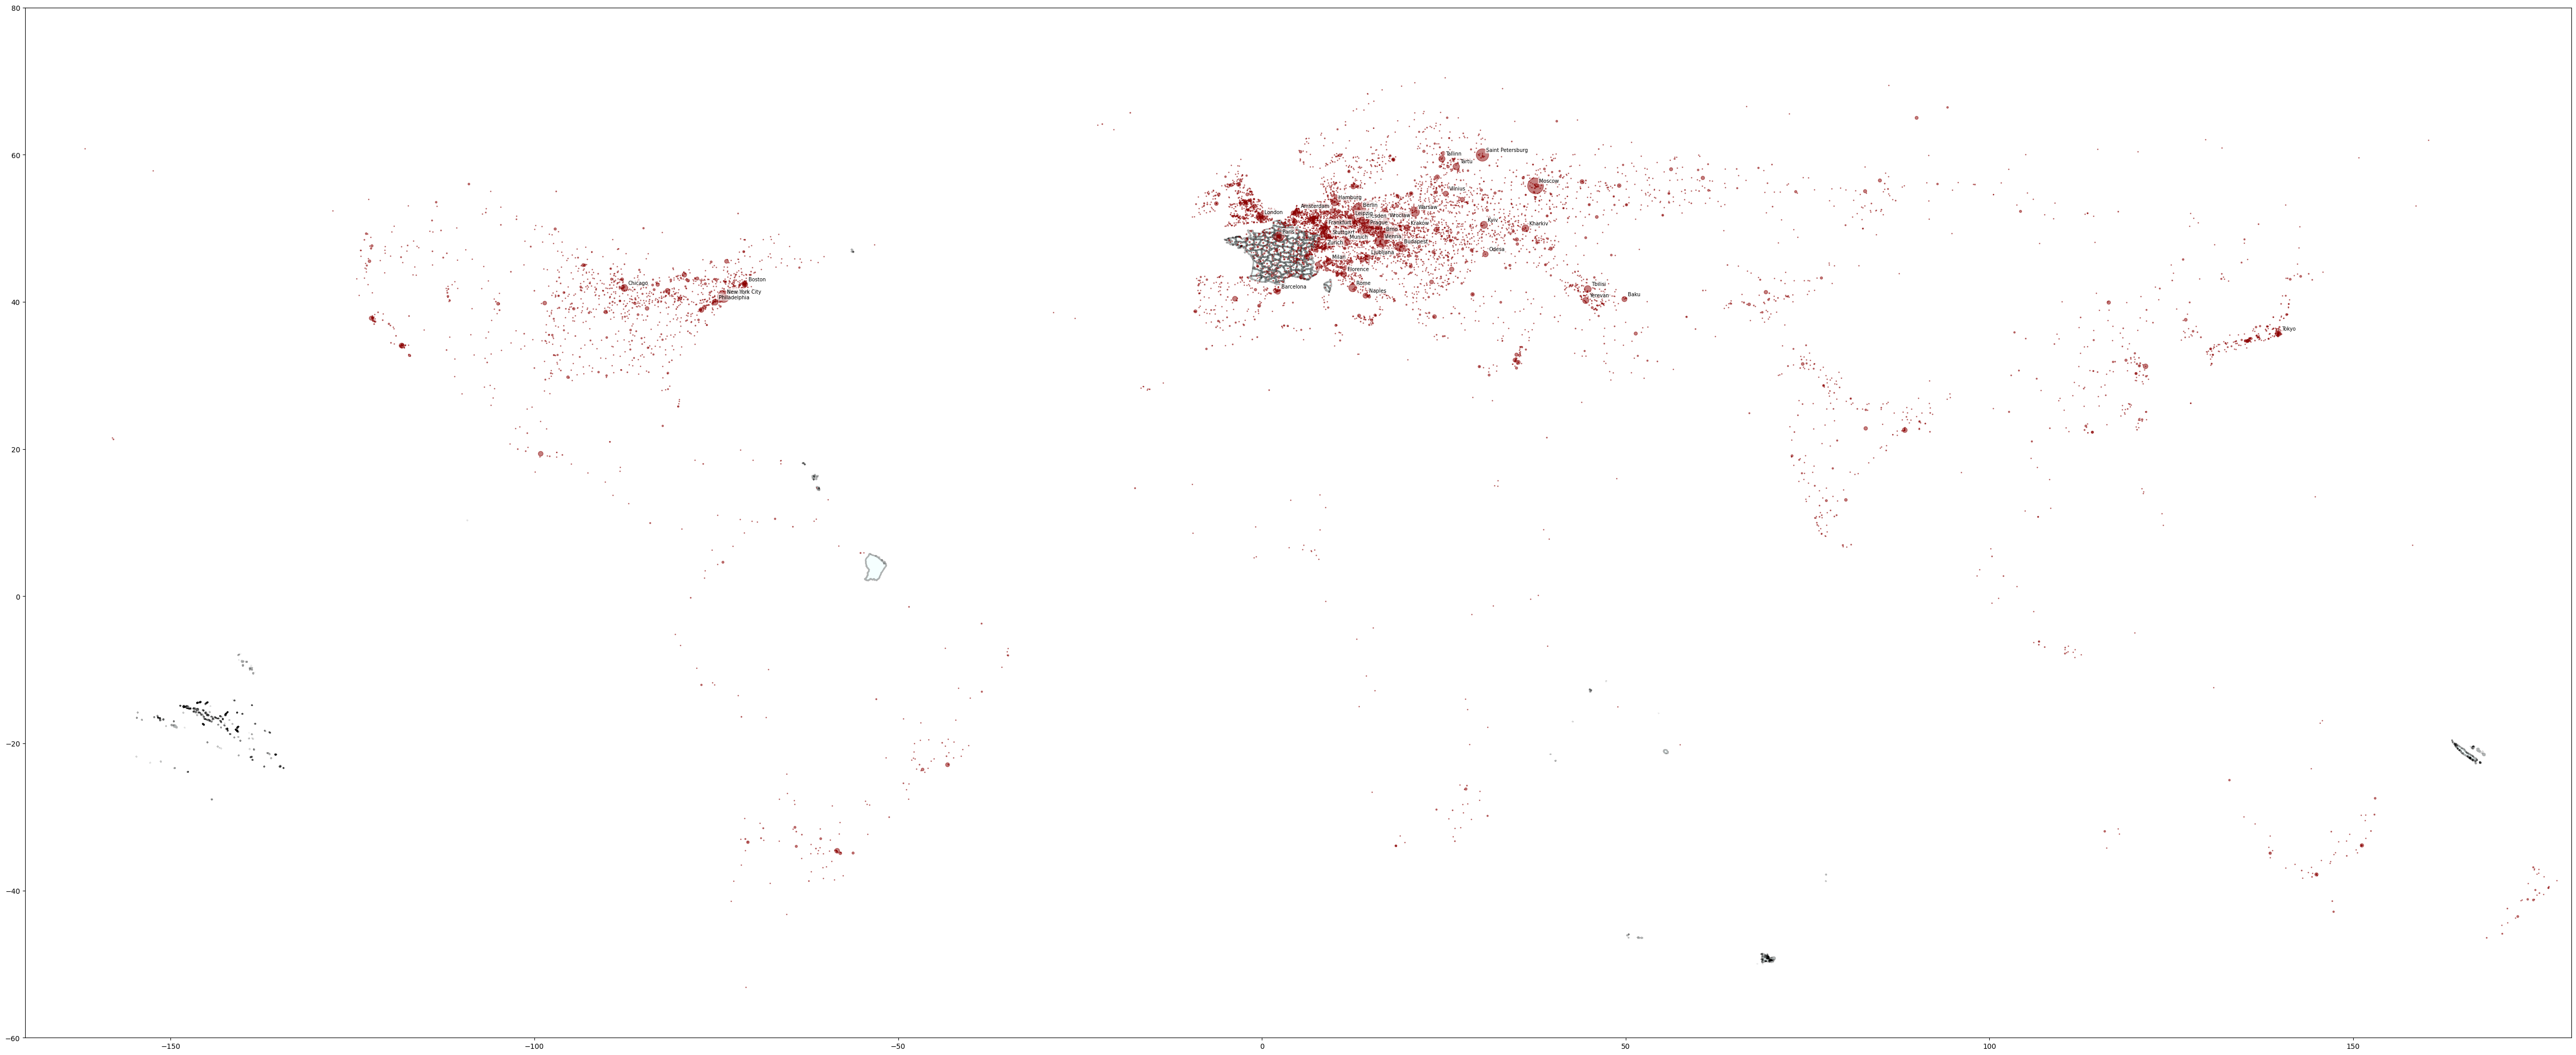

Done -> inspect picture


In [28]:
### Draw the world map


ax = france.plot(color="LightCyan", alpha=0.3, 
                edgecolor="black", linewidth=2, figsize=(64,48))

# If we want to exclude the Antarctic region
ax.set_xlim(-170,180)
ax.set_ylim(-60, 80)

# We can now plot our ``GeoDataFrame``.
birth_gdf.plot(ax=ax, color="DarkRed", markersize='number', alpha=0.5)
# Add labels where number > 100
for _, row in birth_gdf[birth_gdf['number'] > 50].iterrows():
    ax.annotate(
        text=row['labelPlace'],          # e.g. "Boston"
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),              # offset in points
        textcoords="offset points",
        fontsize=7,
        color="Black",
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="none",
            alpha=0.7
        )
    )

f_address = "images/birth_places_geopandas.png"
plt.savefig(f_address)
plt.show()
print('Done -> inspect picture')
plt.close()

### Join regions and inspect

We use here spatial joins and associate a region to each place

In [93]:
### GeoPandas spatial join

w_birth_gdf= birth_gdf.sjoin(italy) #, how='left')
w_birth_gdf.iloc[[1,5,10]]

,uriPlace,labelPlace,geometry,number,index_right,source,id,name
10,http://www.wikidata.org/entity/Q100046,Cavezzo,POINT (11.03071 44.83703),1,18,https://simplemaps.com,IT45,Emilia-Romagna
68,http://www.wikidata.org/entity/Q100943,Sorbolo,POINT (10.44858 44.84628),1,18,https://simplemaps.com,IT45,Emilia-Romagna
248,http://www.wikidata.org/entity/Q102634,Monsummano Terme,POINT (10.81667 43.86667),1,7,https://simplemaps.com,IT52,Tuscany


In [95]:
### Count by region (sum number of each place in the region)
swb = w_birth_gdf.groupby(['name'], as_index=False)['number'].sum()
#swb = swb.set_index('FID', drop=False)
print(len(swb))
swb.sort_values('number', ascending=False).head(24)


19


,name,number
16,Tuscany,157
8,Lombardy,155
6,Lazio,137
4,Emilia-Romagna,106
11,Piedmont,101
18,Veneto,82
14,Sicilia,81
5,Friuli Venezia Giulia,57
12,Puglia,36
3,Campania,34


In [97]:
### Normal Pandas join: add polygons to aggregated regions 
geom_swb=pd.merge(italy, swb, left_on='name', right_on='name', 
                  how='left')

geom_swb.head(3)

,source,id,name,geometry,number
0,https://simplemaps.com,IT23,Valle d'Aosta,"POLYGON ((7.84962 45.93971, 7.85593 45.91932, ...",NaN
1,https://simplemaps.com,IT21,Piedmont,"POLYGON ((7.07537 45.46629, 7.08926 45.47706, ...",101.0
2,https://simplemaps.com,IT42,Liguria,"POLYGON ((7.68793 44.0908, 7.70933 44.09152, 7...",15.0


In [36]:
"""grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)
"""
### simplify geometry 
## https://www.statology.org/how-to-simplify-geographic-data-using-geopandas/
geom_swb["geometry"] = (
    geom_swb.simplify(tolerance=0.5)
)

In [37]:
### range
max = geom_swb.number.max()

# Create the choropleth map
fig = px.choropleth_map(
    geom_swb,
    geojson=geom_swb.__geo_interface__,
    map_style='white-bg',
    locations=geom_swb.index,
    color='number',  # Replace with your actual column name
    color_continuous_scale='Blues',
    range_color=(0, max),  # Replace with your actual range
    zoom=1,
    hover_name='REGION_x',
    center={'lat': 47, 'lon': 8.5},
    height=600,
    width=800

)

f_address = "interactive_images/birth_places_regions_choropleth.html"
fig.write_html(f_address)
# Show the plot
#fig.show()

## Analyse using periods

In [38]:
### Imputed activity periods
l_10 = list(range(1781, 1991, 10))
print(l_10[:5],l_10[-5:])

[1781, 1791, 1801, 1811, 1821] [1941, 1951, 1961, 1971, 1981]


In [39]:
### convert birthYear to integer
df_p.birthYear = df_p.birthYear.apply(lambda x : int(x))

In [40]:
try:
    df_p = df_p.drop('len_coord', axis=1)
except Exception as e:
    print(e)
df_p.head(2)

"['len_coord'] not found in axis"


,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace
0,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,1929,male,Aalen,POINT(10.093611 48.837222),http://www.wikidata.org/entity/Q3951
1,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,1892,male,Holstebro,POINT(8.617500 56.358056),http://www.wikidata.org/entity/Q27678


In [41]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# On ajoute une nouvelle colonne qui contient la période sur la base de la liste précédente
# et de la valeur de l'année
df_p['periods'] = pd.cut(df_p['birthYear'], l_10, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
df_p['periods'] = df_p['periods'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

df_p=df_p.sort_values(by='periods')

# Inspection
df_p.iloc[[1,5,10]]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods
17614,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT(11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790
10198,http://www.wikidata.org/entity/Q252265,Theodor von Grotthuss,1785,male,Leipzig,POINT(12.374733 51.340632),http://www.wikidata.org/entity/Q2079,1781-1790
14595,http://www.wikidata.org/entity/Q4740382,Amasa Holcomb,1787,male,Southwick,POINT(-72.770833 42.054722),http://www.wikidata.org/entity/Q2302156,1781-1790


In [42]:
p_gr_per = df_p.groupby(by=['uriPlace', 'labelPlace', 'periods', 'geometry'], observed=True, as_index=False).size()
p_gr_per.columns=['uriPlace', 'labelPlace', 'period', 'coordinates', 'size']
#p_grp.geometry = gpd.GeoSeries.from_wkt(p_gr["coordinates"])
p_gr_per=p_gr_per.sort_values(by='period')
p_gr_per.head()


,uriPlace,labelPlace,period,coordinates,size
8341,http://www.wikidata.org/entity/Q38380,Angers,1781-1790,POINT(-0.555555 47.472778),1
4959,http://www.wikidata.org/entity/Q20485,Santa Vittoria d'Alba,1781-1790,POINT(7.933333 44.700000),1
10741,http://www.wikidata.org/entity/Q544501,Stadthagen,1781-1790,POINT(9.206944 52.324722),1
10830,http://www.wikidata.org/entity/Q5540,Penza,1781-1790,POINT(45.000000 53.200000),1
4632,http://www.wikidata.org/entity/Q196786,Uglich,1781-1790,POINT(38.333333 57.533333),1


In [43]:

### Créer un dataframe geopandas avec une colonne contenant une géométrie 
# https://geopandas.org/en/stable/gallery/create_geopandas_from_pandas.html
birth_p_grp = gpd.GeoDataFrame(
    p_gr_per, 
    ### Here we use it
    geometry=gpd.GeoSeries.from_wkt(p_gr_per.coordinates), crs=4326
)

birth_p_grp.head(3)



,uriPlace,labelPlace,period,coordinates,size,geometry
8341,http://www.wikidata.org/entity/Q38380,Angers,1781-1790,POINT(-0.555555 47.472778),1,POINT (-0.55556 47.47278)
4959,http://www.wikidata.org/entity/Q20485,Santa Vittoria d'Alba,1781-1790,POINT(7.933333 44.700000),1,POINT (7.93333 44.7)
10741,http://www.wikidata.org/entity/Q544501,Stadthagen,1781-1790,POINT(9.206944 52.324722),1,POINT (9.20694 52.32472)


In [44]:
### Create columns for long / lat
birth_p_grp['long'] = birth_p_grp['geometry'].x
birth_p_grp['lat'] = birth_p_grp['geometry'].y
birth_p_grp.head()

,uriPlace,labelPlace,period,coordinates,size,geometry,long,lat
8341,http://www.wikidata.org/entity/Q38380,Angers,1781-1790,POINT(-0.555555 47.472778),1,POINT (-0.55556 47.47278),-0.555555,47.472778
4959,http://www.wikidata.org/entity/Q20485,Santa Vittoria d'Alba,1781-1790,POINT(7.933333 44.700000),1,POINT (7.93333 44.7),7.933333,44.700000
10741,http://www.wikidata.org/entity/Q544501,Stadthagen,1781-1790,POINT(9.206944 52.324722),1,POINT (9.20694 52.32472),9.206944,52.324722
10830,http://www.wikidata.org/entity/Q5540,Penza,1781-1790,POINT(45.000000 53.200000),1,POINT (45 53.2),45.000000,53.200000
4632,http://www.wikidata.org/entity/Q196786,Uglich,1781-1790,POINT(38.333333 57.533333),1,POINT (38.33333 57.53333),38.333333,57.533333


In [45]:
# now just plot it on a map with evolution by time
# https://plotly.com/python/animations/
# https://plotly.com/python/scatter-plots-on-maps/

# np.log(s) * 1000
size = [s*5 if s != 0 else 0 for s in birth_p_grp["size"]]




fig = px.scatter_geo(
    birth_p_grp,
    lon="long",
    lat="lat",
    size=size,
    hover_name = "labelPlace",
    animation_frame= "period",
    width=1400, height=600,
    color_discrete_sequence=['red'],
    title="Evolution of birth places through time"
)
    
fig.layout.updatemenus[0].buttons[0].args[1]["frame"] = {"duration": 1500, "redraw": True}
fig.layout.updatemenus[0].buttons[0].args[1]["transition"] = {"duration": 800, "easing": "cubic-in-out"}


fig.update_layout(
    mapbox={"style": "carto-positron", "zoom":2},
    margin={"l": 0, "r": 20, "t": 30, "b": 200}
)



fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 1000
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 20

### Enregistrer l'image, puis l'ouvrir dans un autre onglet du navigateur
f_address = "interactive_images/birth_places_periods.html"
fig.write_html(f_address)
#fig.show()
plt.close()


### Merge persons and territories

This merge provides regions as additional properties of persons

In [46]:
with open('geo_data/World_Regions_6144914380456424035.geojson') as f:
    geojson = json.load(f)

pprint.pprint(geojson['features'][3]['properties'])

{'FID': 4,
 'REGION': 'Central America',
 'SQKM': 2480421.615,
 'SQMI': 957692.30734}


In [47]:
print([f['properties']['FID'] for f in geojson['features']][:3])

[1, 2, 3]


In [48]:
## dataframe GeoPandas from geojson features
world = gpd.GeoDataFrame.from_features(geojson['features'])
### this is needed with this import procedure
world.set_crs(epsg=4326, inplace=True)
world.head()

,geometry,FID,REGION,SQMI,SQKM
0,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580...",1,Asiatic Russia,4.987737e+06,1.291823e+07
1,"MULTIPOLYGON (((158.88218 -54.71139, 158.87967...",2,Australia/New Zealand,3.077219e+06,7.969992e+06
2,"MULTIPOLYGON (((-60.92305 10.79722, -60.94445 ...",3,Caribbean,8.919361e+04,2.310113e+05
3,"MULTIPOLYGON (((-81.67847 7.38861, -81.64945 7...",4,Central America,9.576923e+05,2.480422e+06
4,"POLYGON ((53.90564 37.35086, 53.67731 37.33536...",5,Central Asia,1.612212e+06,4.175626e+06


In [49]:
### Inspect the projection
pprint.pprint(world.crs)

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich



In [50]:
world_filepath = 'geo_data/World_Regions_6144914380456424035.geojson'
## dataframe GeoPandas
world = gpd.read_file(world_filepath)
world.head()

,FID,REGION,SQMI,SQKM,geometry
0,1,Asiatic Russia,4.987737e+06,1.291823e+07,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,2,Australia/New Zealand,3.077219e+06,7.969992e+06,"MULTIPOLYGON (((158.88218 -54.71139, 158.87967..."
2,3,Caribbean,8.919361e+04,2.310113e+05,"MULTIPOLYGON (((-60.92305 10.79722, -60.94445 ..."
3,4,Central America,9.576923e+05,2.480422e+06,"MULTIPOLYGON (((-81.67847 7.38861, -81.64945 7..."
4,5,Central Asia,1.612212e+06,4.175626e+06,"POLYGON ((53.90564 37.35086, 53.67731 37.33536..."


In [51]:
### Cleaned up dataframe
df_p.iloc[[1,5,10]]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods
17614,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT(11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790
10198,http://www.wikidata.org/entity/Q252265,Theodor von Grotthuss,1785,male,Leipzig,POINT(12.374733 51.340632),http://www.wikidata.org/entity/Q2079,1781-1790
14595,http://www.wikidata.org/entity/Q4740382,Amasa Holcomb,1787,male,Southwick,POINT(-72.770833 42.054722),http://www.wikidata.org/entity/Q2302156,1781-1790


In [52]:
### create a geo data frame

gdf_p = gpd.GeoDataFrame(
    df_p, 
    ### Here we use it
    geometry=gpd.GeoSeries.from_wkt(df_p.geometry), crs=4326
)

gdf_p.head(3)



,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods
18784,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.57861 46.06028),http://www.wikidata.org/entity/Q654153,1781-1790
17614,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.07639 51.46472),http://www.wikidata.org/entity/Q699082,1781-1790
20074,http://www.wikidata.org/entity/Q874465,József Csorba,1789,male,Vynohradiv,POINT (23.03306 48.13972),http://www.wikidata.org/entity/Q752334,1781-1790


In [53]:
### spatial join : if POINT is inside REGION -> join 
# per person we add the region of birth
pgr_reg = gdf_p.sjoin(world)
pgr_reg.iloc[[1,5,10]]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,FID,REGION,SQMI,SQKM
17614,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.07639 51.46472),http://www.wikidata.org/entity/Q699082,1781-1790,21,22,Western Europe,4.233073e+05,1.096365e+06
10198,http://www.wikidata.org/entity/Q252265,Theodor von Grotthuss,1785,male,Leipzig,POINT (12.37473 51.34063),http://www.wikidata.org/entity/Q2079,1781-1790,21,22,Western Europe,4.233073e+05,1.096365e+06
14595,http://www.wikidata.org/entity/Q4740382,Amasa Holcomb,1787,male,Southwick,POINT (-72.77083 42.05472),http://www.wikidata.org/entity/Q2302156,1781-1790,22,23,Northern America,8.292643e+06,2.147793e+07


In [54]:
### drop not neede column
pgr_reg = pgr_reg.drop([ 'index_right', 'SQMI','SQKM'], axis=1)
pgr_reg.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION
18784,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.57861 46.06028),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe
17614,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.07639 51.46472),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe


#### Prepare the data for the bivariate analysis, cf. challenge da3

In [55]:
file_address='da_data/da3-birthYear-gender-region.csv'
pgr_reg.to_csv(file_address, index=False)

### Merge persons and countries

In [74]:
### Source Eurostat: https://ec.europa.eu/eurostat/web/gisco/geodata/administrative-units/countries
## © EuroGeographics for the administrative boundaries
countries_filepath = 'geo_data/CNTR_RG_03M_2024_4326.geojson'
#countries_filepath = 'geo_data/countries.geojson'
## dataframe GeoPandas
countries = gpd.read_file(countries_filepath)
countries.head()

,CNTR_ID,CNTR_NAME,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM,geometry
0,DJ,جيبوتي-Djibouti-Jabuuti,Djibouti,Djibouti,DJI,UN Member State,Djibouti,F,F,F,Dschibuti,"MULTIPOLYGON (((43.15633 12.64836, 43.29442 12..."
1,DK,Danmark,Denmark,Danemark,DNK,UN Member State,Copenhagen,T,F,F,Dänemark,"MULTIPOLYGON (((15.11729 55.01314, 15.06971 54..."
2,DM,Dominica-Dominique,Dominica,Dominique,DMA,UN Member State,Roseau,F,F,F,Dominica,"POLYGON ((-61.25941 15.25229, -61.27394 15.243..."
3,DO,República Dominicana,Dominican Republic,République dominicaine,DOM,UN Member State,Santo Domingo,F,F,F,Dominikanische Republik,"MULTIPOLYGON (((-70.80653 19.874, -70.77783 19..."
4,DZ,الجزائر,Algeria,Algérie,DZA,UN Member State,Algiers,F,F,F,Algerien,"POLYGON ((7.21824 37.08802, 7.27244 37.06817, ..."


In [75]:
countries.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   CNTR_ID    263 non-null    object  
 1   CNTR_NAME  263 non-null    object  
 2   NAME_ENGL  263 non-null    object  
 3   NAME_FREN  244 non-null    object  
 4   ISO3_CODE  263 non-null    object  
 5   SVRG_UN    263 non-null    object  
 6   CAPT       233 non-null    object  
 7   EU_STAT    263 non-null    object  
 8   EFTA_STAT  263 non-null    object  
 9   CC_STAT    263 non-null    object  
 10  NAME_GERM  243 non-null    object  
 11  geometry   263 non-null    geometry
dtypes: geometry(1), object(11)
memory usage: 24.8+ KB


In [76]:
pprint.pprint(countries.crs)

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich



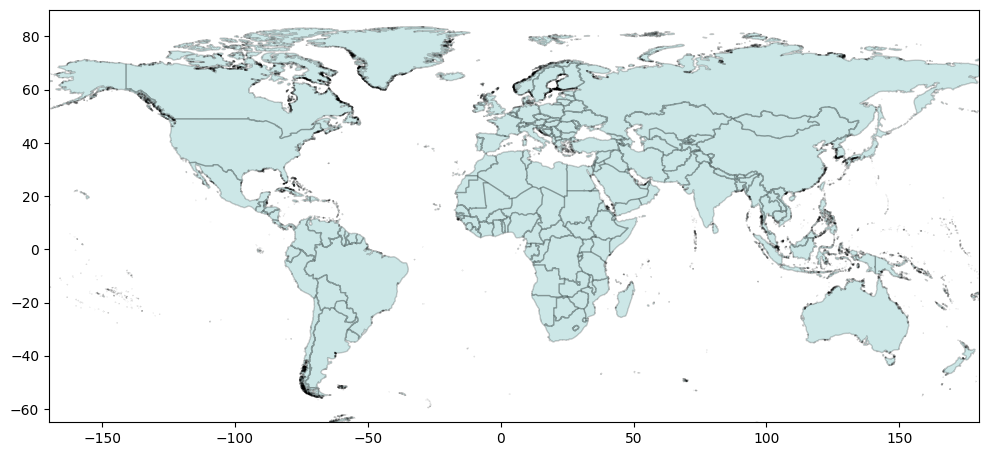

In [77]:
### Draw the world map

## GeoPandas documentation
# https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html

# If we want to exclude the Antarctic region
#countries.clip([-180.0, -10.0, 180.0, 90.0])

ax = countries.plot(color="DarkCyan", alpha=0.2, edgecolor="black", figsize=(12,9))

# If we want to exclude the Antarctic region
ax.set_xlim(-170,180)
ax.set_ylim(-65, 90)


plt.show()



In [78]:
### spatial join : if POINT is inside REGION -> join 
# per person we add the region of birth
pgr_reg_countries = pgr_reg.sjoin(countries)
pgr_reg_countries.iloc[[1,5,10]]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,...,CNTR_NAME,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM
17614,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.07639 51.46472),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,...,Deutschland,Germany,Allemagne,DEU,UN Member State,Berlin,T,F,F,Deutschland
10198,http://www.wikidata.org/entity/Q252265,Theodor von Grotthuss,1785,male,Leipzig,POINT (12.37473 51.34063),http://www.wikidata.org/entity/Q2079,1781-1790,22,Western Europe,...,Deutschland,Germany,Allemagne,DEU,UN Member State,Berlin,T,F,F,Deutschland
14595,http://www.wikidata.org/entity/Q4740382,Amasa Holcomb,1787,male,Southwick,POINT (-72.77083 42.05472),http://www.wikidata.org/entity/Q2302156,1781-1790,23,Northern America,...,United States,United States,États-Unis,USA,UN Member State,"Washington, D.C.",F,F,F,Vereinigten Staaten


In [79]:
pgr_reg_countries.columns

Index(['uriPer', 'labelPer', 'birthYear', 'gender', 'labelPlace', 'geometry',
       'uriPlace', 'periods', 'FID', 'REGION', 'index_right', 'CNTR_ID',
       'CNTR_NAME', 'NAME_ENGL', 'NAME_FREN', 'ISO3_CODE', 'SVRG_UN', 'CAPT',
       'EU_STAT', 'EFTA_STAT', 'CC_STAT', 'NAME_GERM'],
      dtype='object')

In [68]:
### drop not neede column
pgr_reg_countries = pgr_reg_countries.drop([ 'index_right'], axis=1)
pgr_reg_countries.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,name,ISO3166-1-Alpha-3,ISO3166-1-Alpha-2
18784,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.57861 46.06028),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,France,-99,-99
17614,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.07639 51.46472),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,Germany,DEU,DE


In [80]:
### drop not neede column
pgr_reg_countries = pgr_reg_countries.drop([ 'index_right', 'NAME_FREN', 'SVRG_UN', 'CAPT',
       'EU_STAT', 'EFTA_STAT', 'CC_STAT', 'NAME_GERM'], axis=1)
pgr_reg_countries.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE
18784,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.57861 46.06028),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,FR,France,France,FRA
17614,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.07639 51.46472),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU


In [81]:
### Create columns for long / lat
pgr_reg_countries['long'] = pgr_reg_countries['geometry'].x
pgr_reg_countries['lat'] = pgr_reg_countries['geometry'].y
pgr_reg_countries.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,long,lat
18784,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.57861 46.06028),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,FR,France,France,FRA,6.578611,46.060278
17614,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.07639 51.46472),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU,11.076389,51.464722
20074,http://www.wikidata.org/entity/Q874465,József Csorba,1789,male,Vynohradiv,POINT (23.03306 48.13972),http://www.wikidata.org/entity/Q752334,1781-1790,8,Eastern Europe,UA,Україна,Ukraine,UKR,23.033056,48.139722
13653,http://www.wikidata.org/entity/Q4274939,Johann Ludwig Georg Meinecke,1781,male,Stadthagen,POINT (9.20694 52.32472),http://www.wikidata.org/entity/Q544501,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU,9.206944,52.324722
9508,http://www.wikidata.org/entity/Q22331669,Carlo Brioschi,1782,male,Milan,POINT (9.19 45.46694),http://www.wikidata.org/entity/Q490,1781-1790,19,Southern Europe,IT,Italia,Italy,ITA,9.190000,45.466944


#### Prepare the data for the bivariate analysis, cf. challenge da3

In [82]:
file_address='da_data/da3-birthYear-gender-region-country.csv'
pgr_reg_countries.to_csv(file_address, index=False)

### Group by regions and periods

In [127]:
reg_per=pgr_reg.groupby(['FID', 'REGION', 'periods'], observed=True, as_index=False).size()
reg_per.head(3)

,FID,REGION,periods,size
0,1,Asiatic Russia,1831-1840,1
1,1,Asiatic Russia,1851-1860,3
2,1,Asiatic Russia,1871-1880,2


In [128]:
### Merge with world to get polygons
geom_reg_per=pd.merge(reg_per, world, left_on='FID', right_on='FID')
geom_reg_per=geom_reg_per.drop(['REGION_y','SQMI','SQKM'], axis=1)
geom_reg_per.columns=['FID', 'name','periods','number','geometry']
geom_reg_per.head(2)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1831-1840,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,1,Asiatic Russia,1851-1860,3,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [129]:
### Transform to geoDataFrame
grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)
grp_geo.head(2)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1831-1840,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,1,Asiatic Russia,1851-1860,3,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [130]:
print(len(grp_geo))

306


In [131]:
### Tableau de contingence
X = "REGION"
Y = "periods"  # "0"

pv_per_reg = pgr_reg[[X,Y]].pivot_table(index=Y,columns=X,observed=True, aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int)
pv_per_reg

REGION,Asiatic Russia,Australia/New Zealand,Caribbean,Central America,Central Asia,Eastern Africa,Eastern Asia,Eastern Europe,European Russia,Micronesia,...,Polynesia,South America,Southeastern Asia,Southern Africa,Southern Asia,Southern Europe,Western Africa,Western Asia,Western Europe,Total
periods,,,,,,,,,,,,,,,,,,,,,
1781-1790,0,0,0,0,0,0,1,22,4,0,...,0,0,0,0,0,19,0,0,43,118
1791-1800,0,0,0,0,0,0,0,29,6,0,...,0,1,0,0,0,21,0,0,72,176
1801-1810,0,0,0,0,0,0,2,34,6,0,...,0,0,0,0,1,22,0,0,95,216
1811-1820,0,0,0,0,0,0,2,26,7,0,...,0,2,0,0,0,30,0,0,100,230
1821-1830,0,0,1,0,0,0,0,33,8,0,...,0,2,0,0,3,22,0,0,115,242
1831-1840,1,1,0,2,0,0,0,42,13,0,...,0,1,0,2,1,31,0,1,137,310
1841-1850,0,1,1,1,1,0,1,78,21,0,...,0,3,1,1,1,39,0,1,144,396
1851-1860,3,4,0,2,0,0,5,89,36,0,...,0,4,0,0,1,53,0,1,198,505
1861-1870,0,5,0,1,1,0,4,85,41,0,...,0,6,0,0,2,48,0,3,193,547


In [132]:
### Table translation
df_t = pv_per_reg.T

In [133]:
df_t[df_t.Total > 200]

periods,1781-1790,1791-1800,1801-1810,1811-1820,1821-1830,1831-1840,1841-1850,1851-1860,1861-1870,1871-1880,...,1891-1900,1901-1910,1911-1920,1921-1930,1931-1940,1941-1950,1951-1960,1961-1970,1971-1980,Total
REGION,,,,,,,,,,,,,,,,,,,,,
Asiatic Russia,0,0,0,0,0,1,0,3,0,2,...,6,18,17,25,45,87,53,15,18,293
Eastern Asia,1,0,2,2,0,0,1,5,4,13,...,19,50,80,146,161,117,122,87,33,862
Eastern Europe,22,29,34,26,33,42,78,89,85,113,...,167,304,281,563,820,716,496,273,226,4548
European Russia,4,6,6,7,8,13,21,36,41,37,...,77,170,146,269,343,199,129,48,46,1665
Northern America,4,7,12,24,18,29,38,48,82,95,...,131,221,322,442,375,401,252,121,63,2795
Northern Europe,25,40,44,39,40,49,64,61,76,59,...,77,125,129,197,161,181,111,89,44,1687
South America,0,1,0,2,2,1,3,4,6,2,...,5,12,18,37,44,67,53,45,30,337
Southern Asia,0,0,1,0,3,1,1,1,2,2,...,10,12,17,59,94,84,89,37,25,445
Southern Europe,19,21,22,30,22,31,39,53,48,72,...,60,88,97,144,203,246,252,258,174,1935


In [134]:
print(list(df_t.index))

['Asiatic Russia', 'Australia/New Zealand', 'Caribbean', 'Central America', 'Central Asia', 'Eastern Africa', 'Eastern Asia', 'Eastern Europe', 'European Russia', 'Micronesia', 'Middle Africa', 'Northern Africa', 'Northern America', 'Northern Europe', 'Polynesia', 'South America', 'Southeastern Asia', 'Southern Africa', 'Southern Asia', 'Southern Europe', 'Western Africa', 'Western Asia', 'Western Europe', 'Total']


In [135]:
grp_geo.head(1)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1831-1840,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [136]:
sel_geo = grp_geo[grp_geo.name.isin(list(df_t.index))].copy(deep=True)
sel_geo.head(2)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1831-1840,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,1,Asiatic Russia,1851-1860,3,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [137]:
print(grp_geo.crs)

EPSG:4326


In [138]:
grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)

### simplify geometry 
## https://www.statology.org/how-to-simplify-geographic-data-using-geopandas/
grp_geo["geometry"] = (
    grp_geo.simplify(tolerance=0.8)
)

In [139]:
grp_geo=grp_geo.sort_values(by='periods')

In [171]:
max = grp_geo.number.max()

# Create the choropleth map
fig = px.choropleth_map(
    grp_geo,
    geojson=grp_geo.__geo_interface__,
    locations=grp_geo.index,
    color='number',  # Replace with your actual column name
    color_continuous_scale='Blues',
    range_color=(0, max),  # Replace with your actual range
    zoom=1,
    #map_style='white-bg',
    hover_name='name',
    center={'lat': 47, 'lon': 8.5},
    height=800,
    width=1000,
    animation_frame="periods",
    #title="Temporal evolution of birth regions"

)


fig.update_layout(
    #mapbox={"style": "carto-positron", "zoom":2},
    margin={"l": 0, "r": 20, "t": 30, "b": 200}
)



fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 2000
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 20



f_address = "interactive_images/birth_periods_regions_choropleth.html"
fig.write_html(f_address)
# Show the plot
# fig.show()

### Group by regions and periods: only female persons

In [156]:
reg_per=pgr_reg[pgr_reg.gender=='female'].groupby(['FID', 'REGION', 'periods'], observed=True, as_index=False).size()
reg_per.head(3)

,FID,REGION,periods,size
0,1,Asiatic Russia,1891-1900,2
1,1,Asiatic Russia,1901-1910,1
2,1,Asiatic Russia,1911-1920,3


In [157]:
### Merge with world to get polygons
geom_reg_per=pd.merge(reg_per, world, left_on='FID', right_on='FID')
geom_reg_per=geom_reg_per.drop(['REGION_y','SQMI','SQKM'], axis=1)
geom_reg_per.columns=['FID', 'name','periods','number','geometry']
geom_reg_per.head(2)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1891-1900,2,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,1,Asiatic Russia,1901-1910,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [158]:
### Transform to geoDataFrame
grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)
grp_geo.head(2)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1891-1900,2,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,1,Asiatic Russia,1901-1910,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [159]:
print(len(grp_geo))

166


In [161]:
### Tableau de contingence
X = "REGION"
Y = "periods"  # "0"

pv_per_reg = pgr_reg[[X,Y]].pivot_table(index=Y,columns=X,observed=True, aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int)
# pv_per_reg

In [163]:
### Table translation
df_t = pv_per_reg.T

In [162]:
# df_t[df_t.Total > 200]

In [164]:
print(list(df_t.index))

['Asiatic Russia', 'Australia/New Zealand', 'Caribbean', 'Central America', 'Central Asia', 'Eastern Africa', 'Eastern Asia', 'Eastern Europe', 'European Russia', 'Micronesia', 'Middle Africa', 'Northern Africa', 'Northern America', 'Northern Europe', 'Polynesia', 'South America', 'Southeastern Asia', 'Southern Africa', 'Southern Asia', 'Southern Europe', 'Western Africa', 'Western Asia', 'Western Europe', 'Total']


In [165]:
grp_geo.head(1)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1891-1900,2,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [166]:
sel_geo = grp_geo[grp_geo.name.isin(list(df_t.index))].copy(deep=True)
sel_geo.head(2)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1891-1900,2,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,1,Asiatic Russia,1901-1910,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [137]:
print(grp_geo.crs)

EPSG:4326


In [167]:
grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)

### simplify geometry 
## https://www.statology.org/how-to-simplify-geographic-data-using-geopandas/
grp_geo["geometry"] = (
    grp_geo.simplify(tolerance=0.8)
)

In [168]:
grp_geo=grp_geo.sort_values(by='periods')

In [170]:
max = grp_geo.number.max()

# Create the choropleth map
fig = px.choropleth_map(
    grp_geo,
    geojson=grp_geo.__geo_interface__,
    locations=grp_geo.index,
    color='number',  # Replace with your actual column name
    color_continuous_scale='RdPu',
    range_color=(0, max),  # Replace with your actual range
    zoom=1,
    #map_style='white-bg',
    hover_name='name',
    center={'lat': 47, 'lon': 8.5},
    height=800,
    width=1000,
    animation_frame="periods",
    #title="Temporal evolution of birth regions"

)


fig.update_layout(
    #mapbox={"style": "carto-positron", "zoom":2},
    margin={"l": 0, "r": 20, "t": 30, "b": 200}
)



fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 2000
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 20



f_address = "interactive_images/birth_periods_regions_choropleth_female.html"
fig.write_html(f_address)
# Show the plot
# fig.show()